# Comparação de Velocidade: NumPy vs PyTorch
Benchmark do tempo de execução de 1000 épocas de treinamento para as duas implementações, comparando a média e a variância.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from numpy.typing import NDArray

import torch
import torch.nn as nn
import torch.optim as optim

from neural_network import NeuralNetwork
from dense_layer import DenseLayer
from activation_function import ReLU, SoftmaxCrossEntropy
from nn_pytorch import PyTorchNeuralNetwork

In [2]:
# Funções Auxiliares copiadas do main.ipynb
def train_test_split(X: NDArray[np.float32], y: NDArray[np.float32], test_size: float = 0.2, shuffle: bool = True):
    num_samples = len(y)
    if shuffle:
        ixs = np.random.permutation(num_samples)
        X = X.iloc[ixs]
        y = y.iloc[ixs]
    test_len = np.floor(test_size * num_samples).astype(np.int32)
    X_test = X[:test_len]
    X_train = X[test_len:]
    y_test = y[:test_len]
    y_train = y[test_len:]
    return X_train, X_test, y_train, y_test 

def to_one_hot(y, num_classes=2):
    y = np.asarray(y, dtype=np.int32).flatten()
    m = y.shape[0]
    Y = np.zeros((num_classes, m), dtype=np.float32)
    Y[y, np.arange(m)] = 1.0
    return Y

def get_mini_batch(X_train: NDArray[np.float32], y_train: NDArray[np.float32], batch_size: int = 32):
    y_len = len(y_train)
    ixs = np.random.permutation(y_len)
    X = X_train.iloc[ixs]
    y = y_train.iloc[ixs]
    batches = []
    for i in range(0, len(X), batch_size):
        X_batch = X[i : i + batch_size].to_numpy().T
        y_batch = to_one_hot(y[i : i + batch_size])
        batches.append((X_batch, y_batch))
    return batches

def normalize(X_train: NDArray[np.float32], X_test: NDArray[np.float32]):
    media = X_train.mean(axis=0)
    desvio = X_train.std(axis=0)
    X_train = (X_train - media) / desvio
    X_test = (X_test - media) / desvio
    return X_train, X_test

In [3]:
# Carregamento e Preparação da Base de Dados
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
X = df
y = pd.Series(data.target)
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_test = normalize(X_train, X_test)

n_features = X_train.shape[1]
lr = 0.001
initialization_method = "xavier"
batch_size = 16

# Configurações do Treinamento e Benchmark
num_epochs = 300
n_runs = 100

In [ ]:
times_np = []
times_pt = []

print(f"Iniciando benchmark de velocidade com {n_runs} execuções de {num_epochs} épocas...")

# Loop de Benchmarking (50 vezes o treinamento completo)
for i in range(n_runs):
    # Inicialização dos Modelos a cada nova execução
    layers = [
        DenseLayer(32, n_features, ReLU(), init_method=initialization_method),
        DenseLayer(16, 32, ReLU(), init_method=initialization_method),
        DenseLayer(8, 16, ReLU(), init_method=initialization_method),
        DenseLayer(2, 8, init_method=initialization_method),
    ]
    model_np = NeuralNetwork(layers, SoftmaxCrossEntropy())

    model_pt = PyTorchNeuralNetwork(n_features, init_method=initialization_method)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model_pt.parameters(), lr=lr)

    # ---------------- Benchmark Custom NumPy ----------------
    start_np = time.perf_counter()
    for e in range(num_epochs):
        mini_batches = get_mini_batch(X_train, y_train, batch_size=batch_size)
        for X_batch, y_batch in mini_batches:
            model_np.fit(X_batch, y_batch, learning_rate=lr)
    times_np.append(time.perf_counter() - start_np)
    
    # ---------------- Benchmark PyTorch ---------------------
    start_pt = time.perf_counter()
    for e in range(num_epochs):
        mini_batches = get_mini_batch(X_train, y_train, batch_size=batch_size)
        model_pt.train()
        for X_batch, y_batch in mini_batches:
            X_tensor = torch.tensor(X_batch.T, dtype=torch.float32)
            y_tensor = torch.tensor(np.argmax(y_batch, axis=0), dtype=torch.long)
            
            optimizer.zero_grad()
            outputs = model_pt(X_tensor)
            loss = criterion(outputs, y_tensor)
            loss.backward()
            optimizer.step()
    times_pt.append(time.perf_counter() - start_pt)

    print(f"Execução {i+1}/{n_runs} concluída. Tempo NumPy: {times_np[-1]:.2f}s, Tempo PyTorch: {times_pt[-1]:.2f}s")

print("Benchmark concluído!")

Iniciando benchmark de velocidade com 100 execuções de 300 épocas...
Execução 1/100 concluída. Tempo NumPy: 1.62s, Tempo PyTorch: 9.09s
Execução 1/100 concluída. Tempo NumPy: 1.62s, Tempo PyTorch: 9.09s
Execução 2/100 concluída. Tempo NumPy: 1.62s, Tempo PyTorch: 8.37s
Execução 2/100 concluída. Tempo NumPy: 1.62s, Tempo PyTorch: 8.37s
Execução 3/100 concluída. Tempo NumPy: 1.57s, Tempo PyTorch: 9.84s
Execução 3/100 concluída. Tempo NumPy: 1.57s, Tempo PyTorch: 9.84s
Execução 4/100 concluída. Tempo NumPy: 1.66s, Tempo PyTorch: 9.21s
Execução 4/100 concluída. Tempo NumPy: 1.66s, Tempo PyTorch: 9.21s
Execução 5/100 concluída. Tempo NumPy: 1.61s, Tempo PyTorch: 9.21s
Execução 5/100 concluída. Tempo NumPy: 1.61s, Tempo PyTorch: 9.21s
Execução 6/100 concluída. Tempo NumPy: 1.67s, Tempo PyTorch: 8.64s
Execução 6/100 concluída. Tempo NumPy: 1.67s, Tempo PyTorch: 8.64s
Execução 7/100 concluída. Tempo NumPy: 1.55s, Tempo PyTorch: 8.18s
Execução 7/100 concluída. Tempo NumPy: 1.55s, Tempo PyTorch:

------------------------------------------------------------
Estatísticas de Tempo de Execução (Por Treinamento Completo):
NumPy Custom - Média: 1.49676 s | Variância: 5.07430e-03 s²
PyTorch      - Média: 8.23029 s | Variância: 3.80754e-01 s²
------------------------------------------------------------


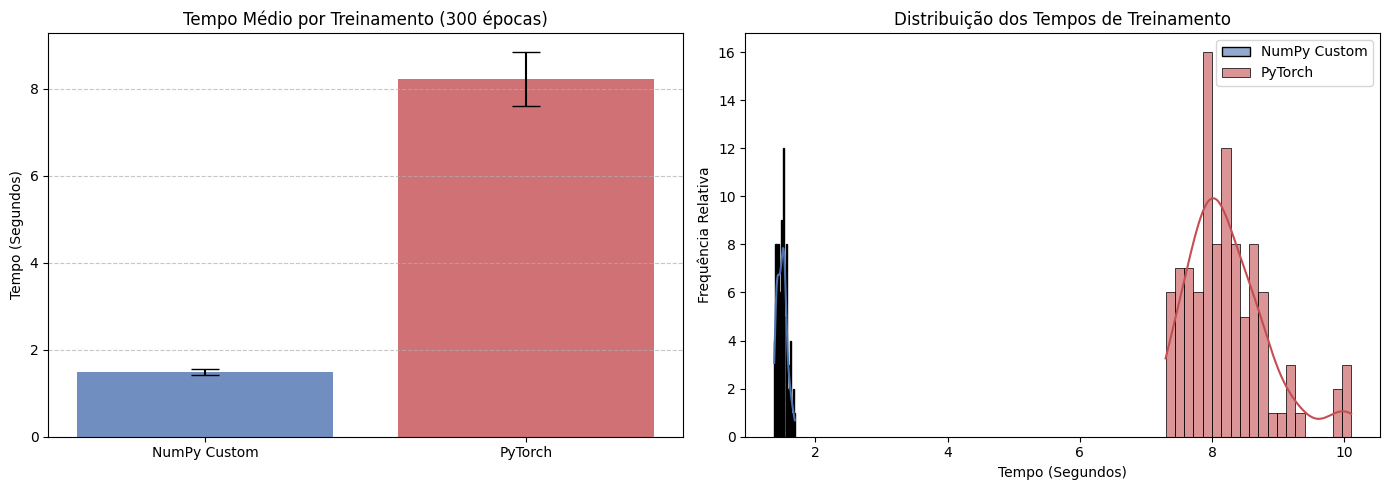

In [5]:
# Geração de Estatísticas
mean_np, var_np = np.mean(times_np), np.var(times_np)
mean_pt, var_pt = np.mean(times_pt), np.var(times_pt)

print("-" * 60)
print("Estatísticas de Tempo de Execução (Por Treinamento Completo):")
print(f"NumPy Custom - Média: {mean_np:.5f} s | Variância: {var_np:.5e} s²")
print(f"PyTorch      - Média: {mean_pt:.5f} s | Variância: {var_pt:.5e} s²")
print("-" * 60)

# Visualização de Resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Tempo Médio de Execução do Treinamento + Desvio Padrão
models = ['NumPy Custom', 'PyTorch']
means = [mean_np, mean_pt]
stds = [np.sqrt(var_np), np.sqrt(var_pt)]

axes[0].bar(models, means, yerr=stds, capsize=10, color=['#4C72B0', '#C44E52'], alpha=0.8)
axes[0].set_title('Tempo Médio por Treinamento (300 épocas)')
axes[0].set_ylabel('Tempo (Segundos)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico 2: Distribuição dos Tempos Recoletados
sns.histplot(times_np, bins=20, label='NumPy Custom', color='#4C72B0', alpha=0.6, kde=True, ax=axes[1])
sns.histplot(times_pt, bins=20, label='PyTorch', color='#C44E52', alpha=0.6, kde=True, ax=axes[1])
axes[1].set_title('Distribuição dos Tempos de Treinamento')
axes[1].set_xlabel('Tempo (Segundos)')
axes[1].set_ylabel('Frequência Relativa')
axes[1].legend()

plt.tight_layout()
plt.show()